Dataset Shape: (7043, 21)

First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streami

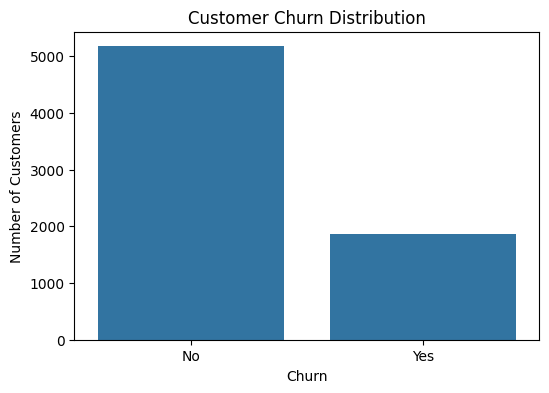

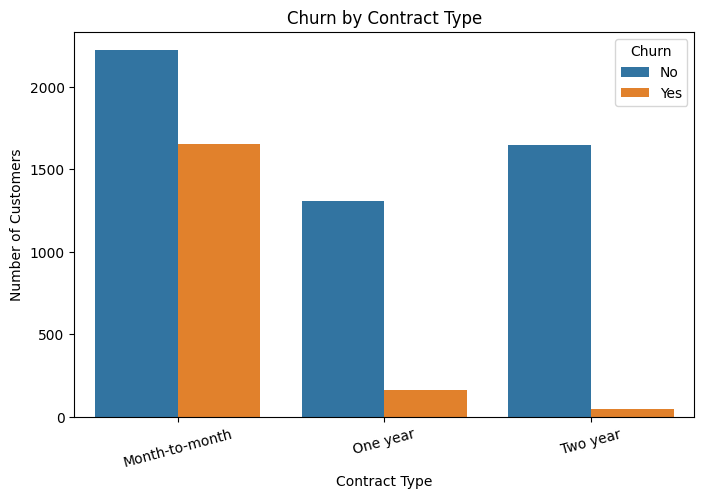

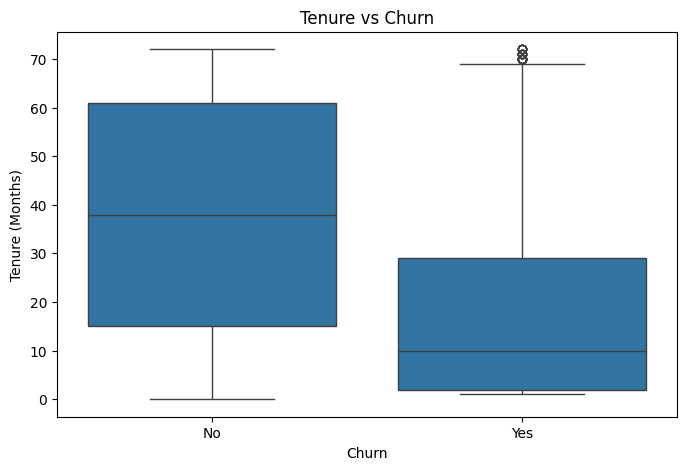

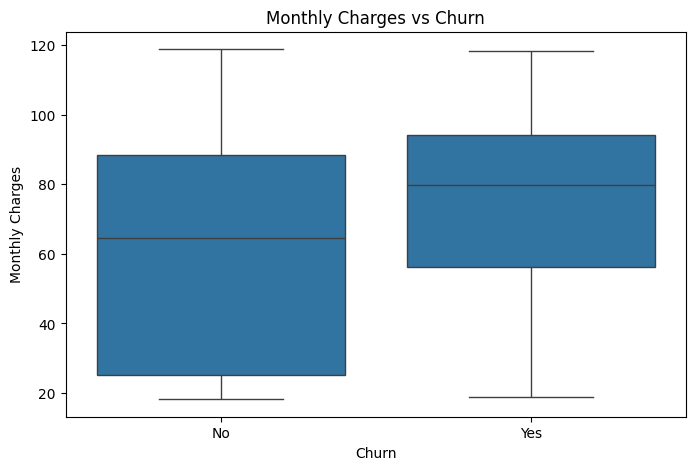


========== AVERAGE VALUES BY CHURN ==========

Average Tenure:
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

Average Monthly Charges:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

Average Total Charges:
Churn
No     2552.882494
Yes    1531.796094
Name: TotalCharges, dtype: float64

Churn by Contract:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858

========== ENCODED DATA ==========
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2      

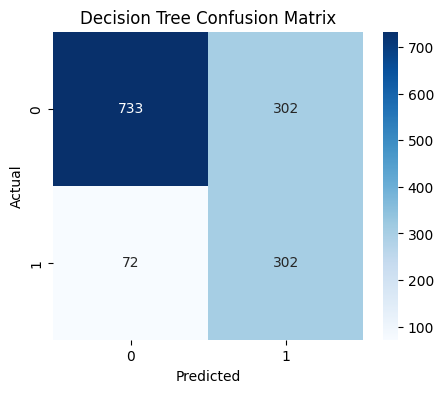


       LOGISTIC REGRESSION RESULTS
Accuracy: 0.7388218594748048
Precision: 0.5051903114186851
Recall: 0.7807486631016043
F1 Score: 0.6134453781512605

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



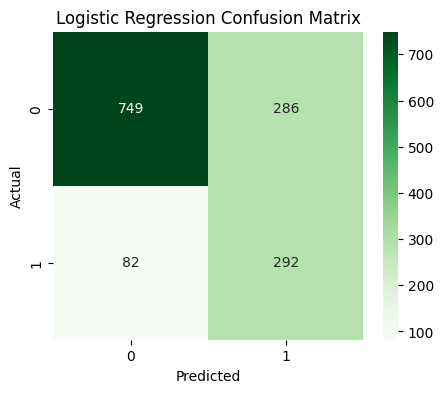


           MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score
0        Decision Tree    0.7346     0.5000  0.8075    0.6176
1  Logistic Regression    0.7388     0.5052  0.7807    0.6134

      TOP 3 FEATURES DRIVING CHURN
                    Feature  Importance
          Contract_Two year    0.405269
          Contract_One year    0.253452
InternetService_Fiber optic    0.111558


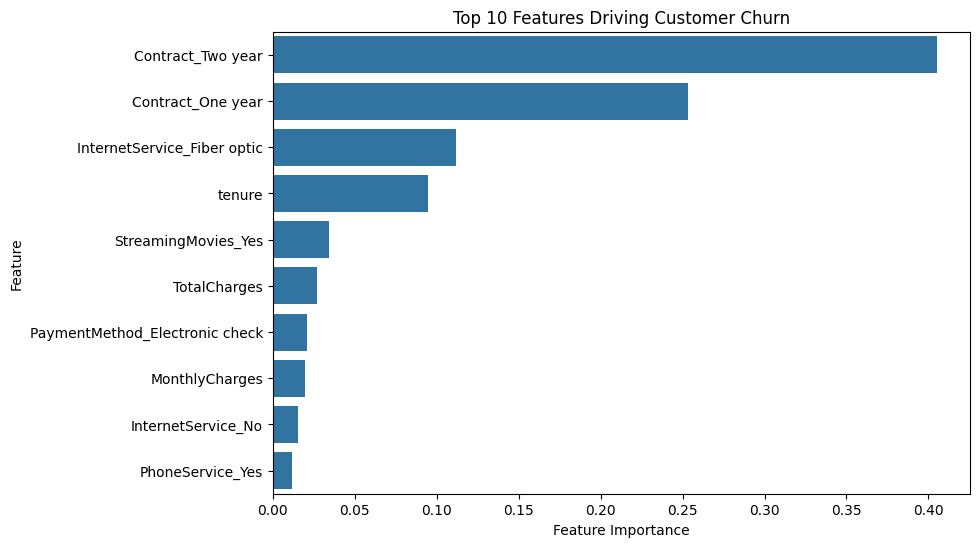

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\n========== DATASET INFO ==========")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== CHURN DISTRIBUTION ==========")
print(df["Churn"].value_counts())

print("\n========== CHURN PERCENTAGE ==========")
print(df["Churn"].value_counts(normalize=True) * 100)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing TotalCharges with median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)
print("\nMissing values after cleaning:")
print(df.isnull().sum())
# Churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# Churn by Contract
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

# Tenure vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

# Monthly Charges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()
print("\n========== AVERAGE VALUES BY CHURN ==========")

print("\nAverage Tenure:")
print(df.groupby("Churn")["tenure"].mean())

print("\nAverage Monthly Charges:")
print(df.groupby("Churn")["MonthlyCharges"].mean())

print("\nAverage Total Charges:")
print(df.groupby("Churn")["TotalCharges"].mean())

print("\nChurn by Contract:")
print(pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100)
# customerID is only an identifier and does not help prediction
df = df.drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})
# One-hot encoding
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)
print("\n========== ENCODED DATA ==========")
print(df_encoded.head())

print("\nEncoded Dataset Shape:", df_encoded.shape)
print("\n========== CLASS IMBALANCE ==========")

print("Churn Counts:")
print(df["Churn"].value_counts())

print("\nChurn Percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]
print("\nNumber of Features:", X.shape[1])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("\n======================================")
print("       DECISION TREE RESULTS")
print("======================================")

print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1 Score:", dt_f1)

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, dt_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("\n======================================")
print("       LOGISTIC REGRESSION RESULTS")
print("======================================")

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Logistic Regression"
    ],
    "Accuracy": [
        dt_accuracy,
        lr_accuracy
    ],
    "Precision": [
        dt_precision,
        lr_precision
    ],
    "Recall": [
        dt_recall,
        lr_recall
    ],
    "F1 Score": [
        dt_f1,
        lr_f1
    ]
})

print("\n======================================")
print("           MODEL COMPARISON")
print("======================================")

print(comparison.round(4))
# TOP 3 FEATURES FROM DECISION TREE
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print("\n======================================")
print("      TOP 3 FEATURES DRIVING CHURN")
print("======================================")

print(feature_importance.head(3).to_string(index=False))
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Driving Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()
top_3 = feature_importance.head(3)["Feature"].tolist()


**Business Summary**

The analysis shows that customer churn is mainly influenced by factors such as contract type, tenure, and monthly charges. Customers with shorter tenures and month-to-month contracts are more likely to leave the company. Higher monthly charges may also increase the likelihood of customers switching to competitors. The models can help the company identify customers who are at higher risk of leaving. By offering targeted discounts, better plans, and retention incentives, the company can reduce churn and improve customer loyalty.